Perform EDA and Predict the sales of the next 7 days from the last date of the Training dataset!

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import mean_squared_error,r2_score,accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.arima.model import ARIMA

In [5]:
df = pd.read_csv('train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

 Coverting date columns into Datetime format


In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)


New Column for Delivery Time ,[Order Date - Ship Date]


In [9]:
df['Delivery Time'] = df['Ship Date'] - df['Order Date']

In [10]:
df['Delivery Time']

,Delivery Time
0,3 days
1,3 days
2,4 days
3,7 days
4,7 days
...,...
9795,7 days
9796,5 days
9797,5 days
9798,5 days


StandardScaler to Normalize Value

In [11]:
scaler= StandardScaler()
df['Sales'] = scaler.fit_transform(df['Sales'].values.reshape(-1,1))

In [12]:
df['City'].value_counts()

,count
City,
New York City,891
Los Angeles,728
Philadelphia,532
San Francisco,500
Seattle,426
...,...
Goldsboro,1
Montebello,1
Abilene,1


In [13]:
df['Category'].value_counts()

,count
Category,
Office Supplies,5909
Furniture,2078
Technology,1813


In [14]:
df[['Category','Sub-Category']].value_counts()

Category         Sub-Category
Office Supplies  Binders         1492
                 Paper           1338
Furniture        Furnishings      931
Technology       Phones           876
Office Supplies  Storage          832
                 Art              785
Technology       Accessories      756
Furniture        Chairs           607
Office Supplies  Appliances       459
                 Labels           357
Furniture        Tables           314
Office Supplies  Envelopes        248
Furniture        Bookcases        226
Office Supplies  Fasteners        214
                 Supplies         184
Technology       Machines         115
                 Copiers           66
Name: count, dtype: int64

In [15]:
#Extract from the Order Date into Year and Month to see the sales of each month and Year

In [16]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month

In [17]:
df['Order Month']

,Order Month
0,11
1,11
2,6
3,10
4,10
...,...
9795,5
9796,1
9797,1
9798,1


In [18]:
df['Order Year']


,Order Year
0,2017
1,2017
2,2017
3,2016
4,2016
...,...
9795,2017
9796,2016
9797,2016
9798,2016


### Visualizing Sales Trends Over Time

First, let's look at how sales have evolved over the years and months. This will help us identify any overarching trends or seasonal patterns.

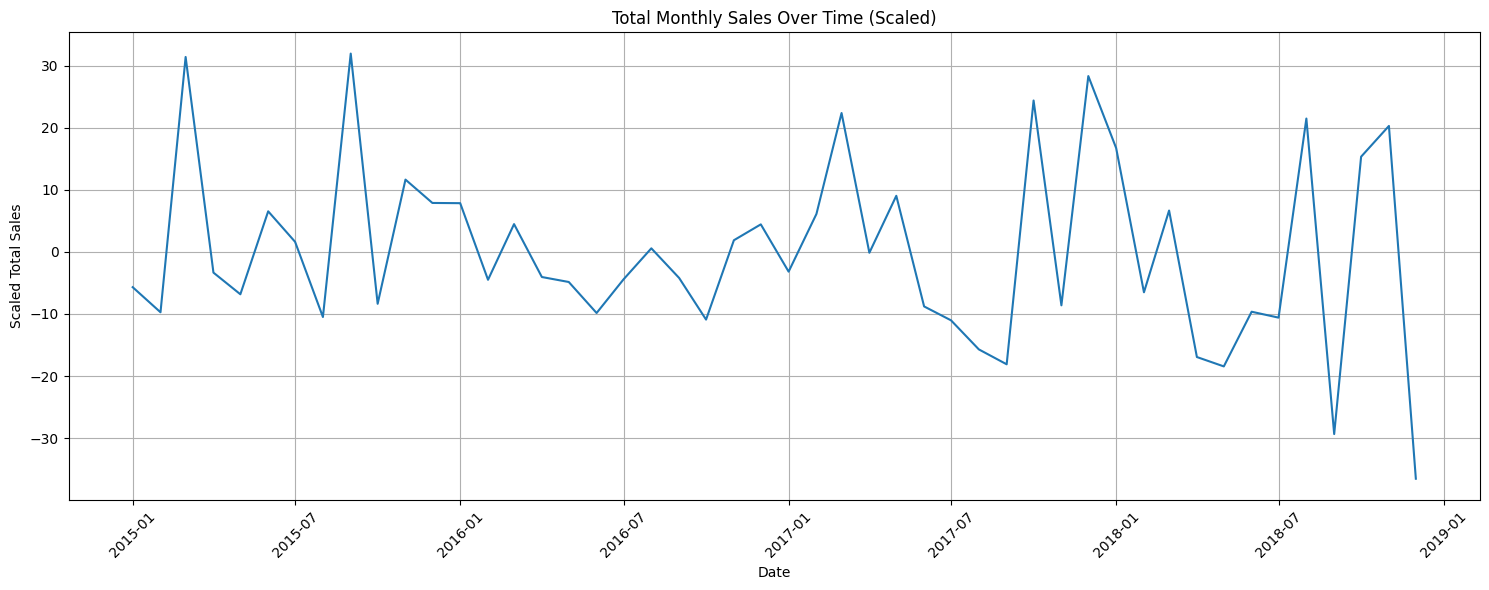

In [19]:
# Aggregate monthly sales
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
monthly_sales['YearMonth'] = pd.to_datetime(monthly_sales['Order Year'].astype(str) + '-' + monthly_sales['Order Month'].astype(str))
monthly_sales = monthly_sales.sort_values('YearMonth')

plt.figure(figsize=(15, 6))
sns.lineplot(x='YearMonth', y='Sales', data=monthly_sales)
plt.title('Total Monthly Sales Over Time (Scaled)')
plt.xlabel('Date')
plt.ylabel('Scaled Total Sales')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Sales Distribution by Category

Next, let's understand which product categories contribute most to the sales. This can highlight key revenue drivers.

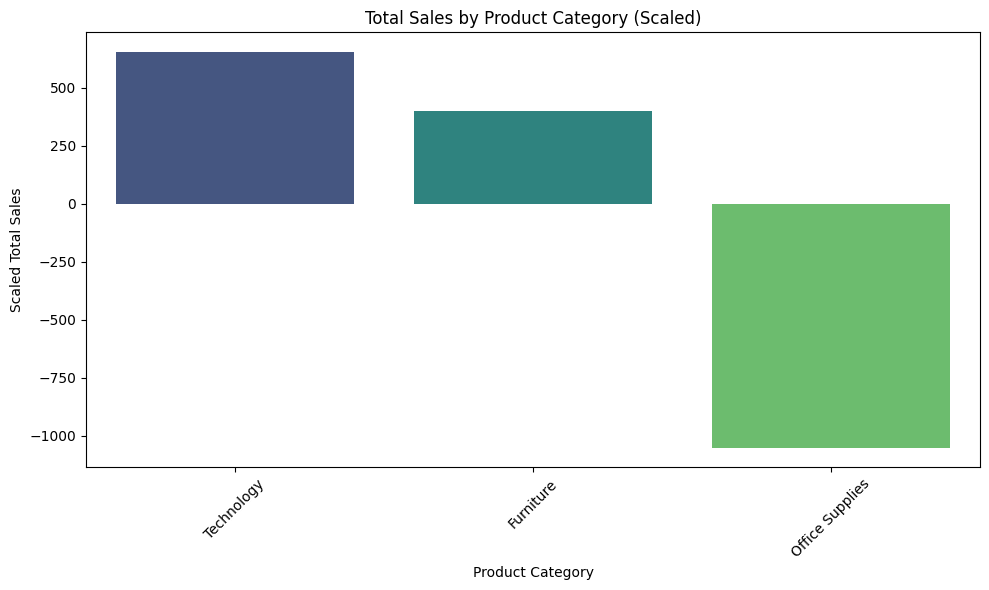

In [20]:
# Aggregate sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Sales', data=category_sales, palette='viridis')
plt.title('Total Sales by Product Category (Scaled)')
plt.xlabel('Product Category')
plt.ylabel('Scaled Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Sales Distribution by Sub-Category

Let's drill down further and examine sales at the sub-category level to get more granular insights.

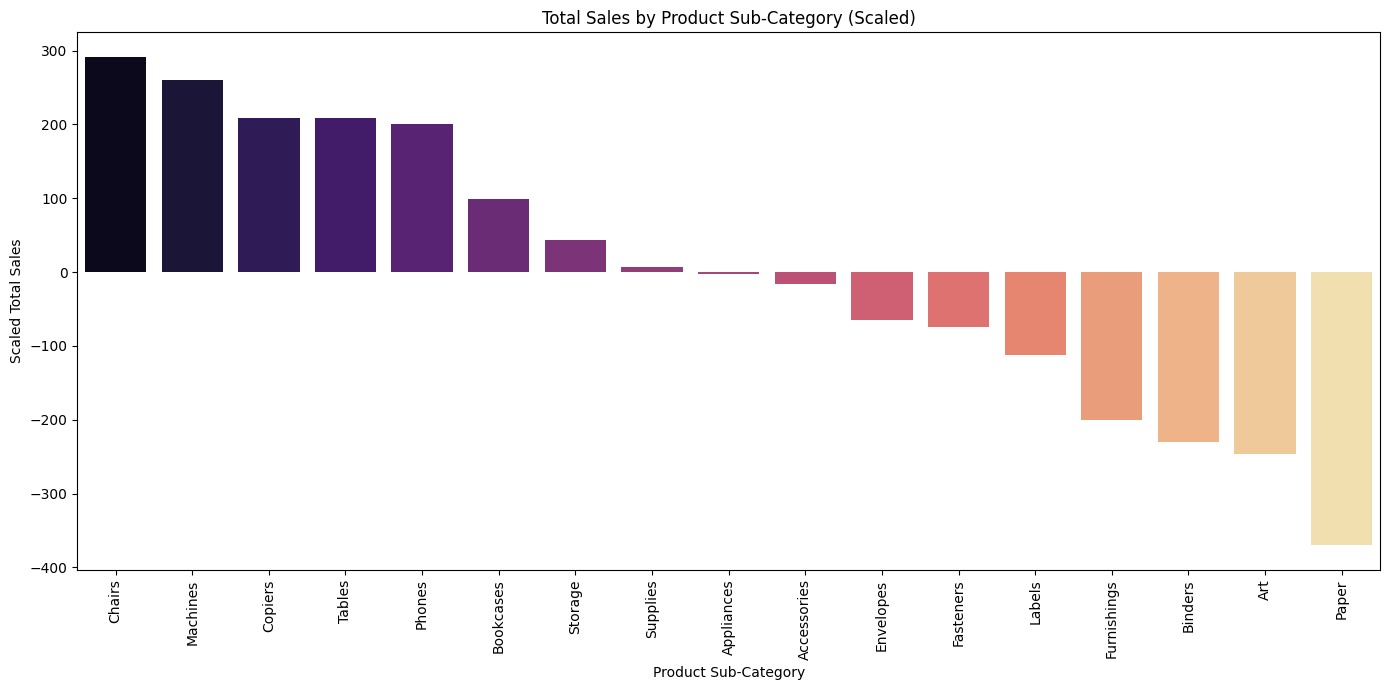

In [21]:
# Aggregate sales by Sub-Category
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(x='Sub-Category', y='Sales', data=subcategory_sales, palette='magma')
plt.title('Total Sales by Product Sub-Category (Scaled)')
plt.xlabel('Product Sub-Category')
plt.ylabel('Scaled Total Sales')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Impact of Delivery Time on Sales Across Categories

To understand how 'Delivery Time' affects 'Sales' across various dimensions, we first need to convert 'Delivery Time' from a timedelta object to a numerical format (days). Then, we'll analyze the average sales and average delivery time for different segments, regions, states, cities, categories, and sub-categories.

In [22]:
# Convert 'Delivery Time' to numerical days
df['Delivery Time Days'] = df['Delivery Time'].dt.days

# Display some descriptive statistics for the new column
print("Delivery Time (in Days) Statistics:")
print(df['Delivery Time Days'].describe())

Delivery Time (in Days) Statistics:
count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Delivery Time Days, dtype: float64


### Sales and Delivery Time by Customer Segment

Let's examine if different customer segments experience different sales patterns based on delivery times.

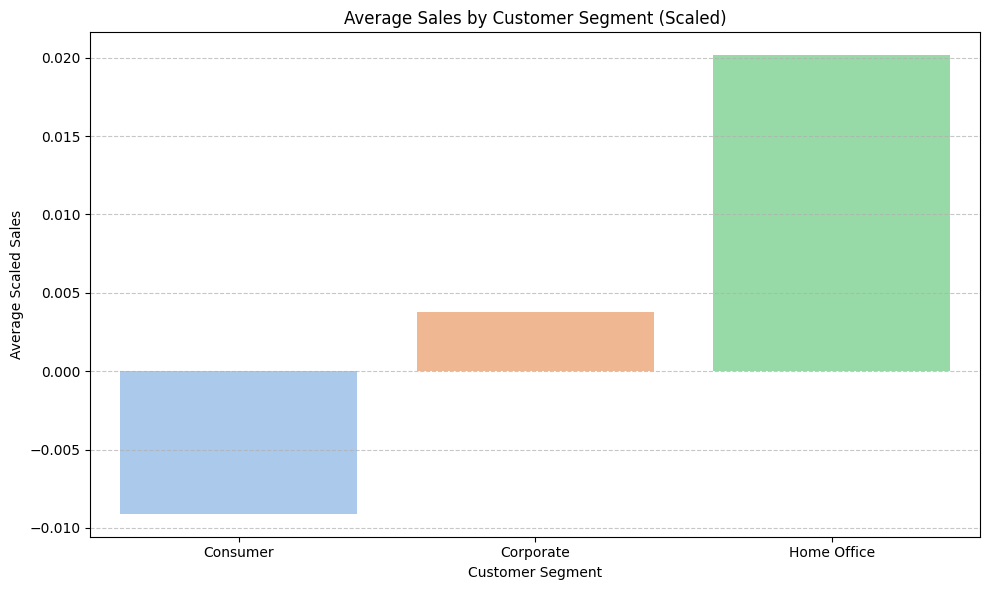

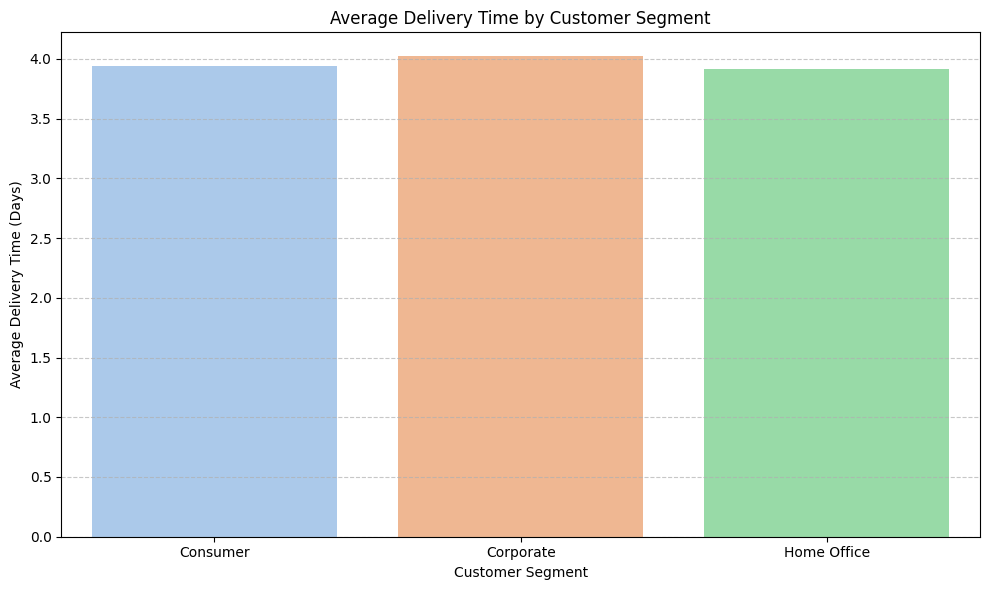

In [23]:
segment_analysis = df.groupby('Segment').agg(
    avg_sales=('Sales', 'mean'),
    avg_delivery_time=('Delivery Time Days', 'mean')
).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Segment', y='avg_sales', data=segment_analysis, palette='pastel', hue='Segment', legend=False)
plt.title('Average Sales by Customer Segment (Scaled)')
plt.xlabel('Customer Segment')
plt.ylabel('Average Scaled Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Segment', y='avg_delivery_time', data=segment_analysis, palette='pastel', hue='Segment', legend=False)
plt.title('Average Delivery Time by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Delivery Time (Days)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Sales and Delivery Time by Region

Now, let's explore if geographical regions show different relationships between sales and delivery speed.

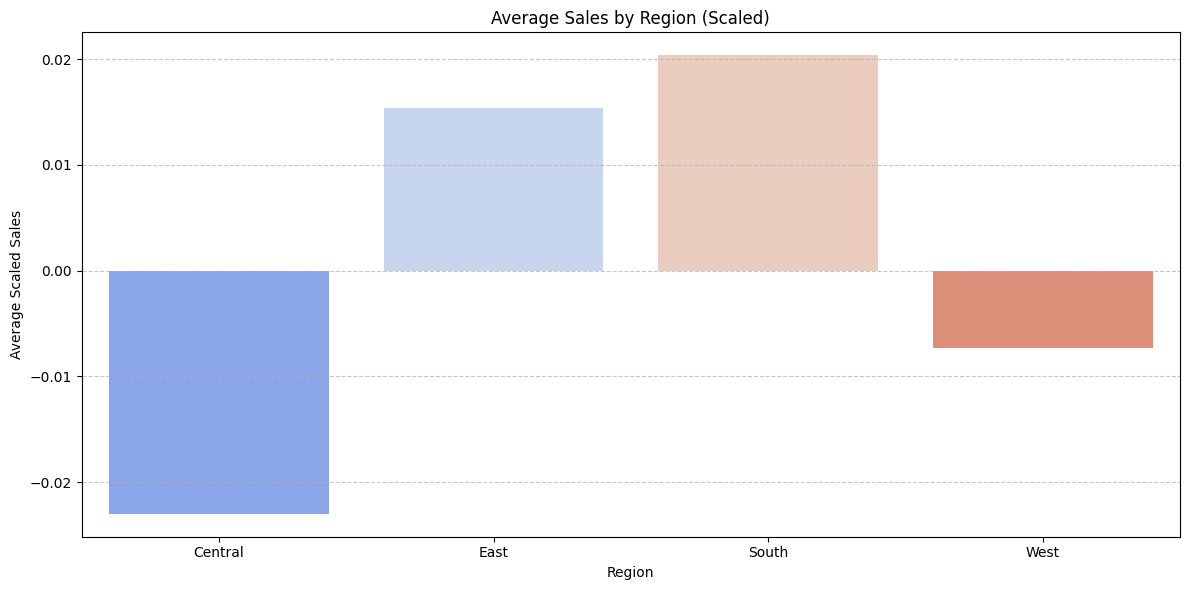

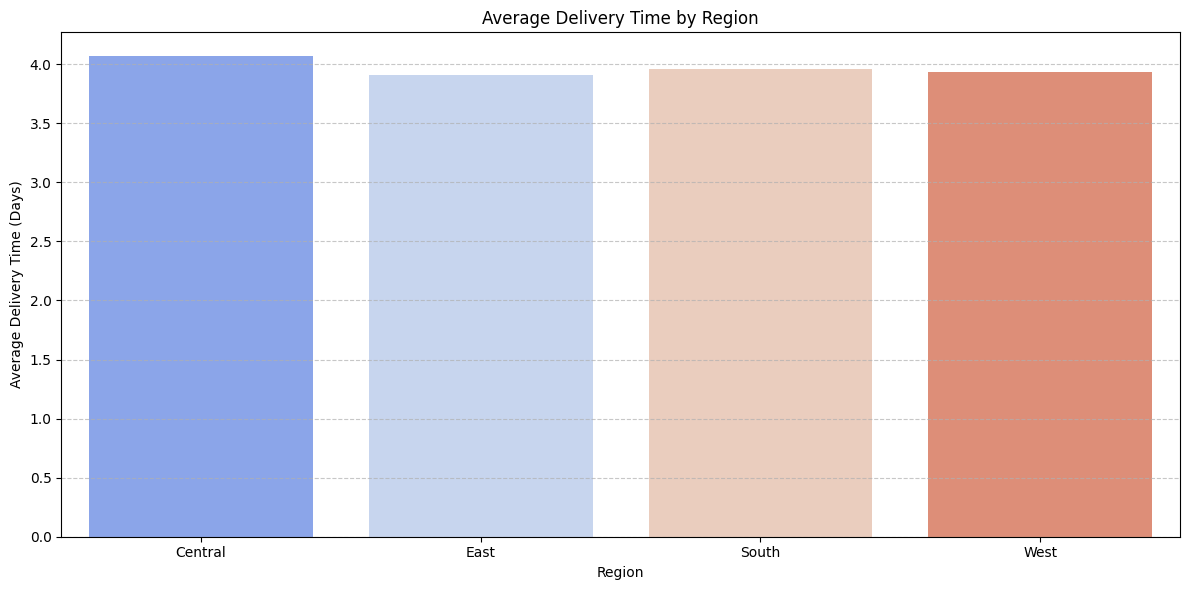

In [24]:
region_analysis = df.groupby('Region').agg(
    avg_sales=('Sales', 'mean'),
    avg_delivery_time=('Delivery Time Days', 'mean')
).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Region', y='avg_sales', data=region_analysis, palette='coolwarm', hue='Region', legend=False)
plt.title('Average Sales by Region (Scaled)')
plt.xlabel('Region')
plt.ylabel('Average Scaled Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Region', y='avg_delivery_time', data=region_analysis, palette='coolwarm', hue='Region', legend=False)
plt.title('Average Delivery Time by Region')
plt.xlabel('Region')
plt.ylabel('Average Delivery Time (Days)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Sales and Delivery Time by Product Category

Finally, let's check if product categories, which have distinct sales volumes, also show variations in delivery times and their impact on sales.

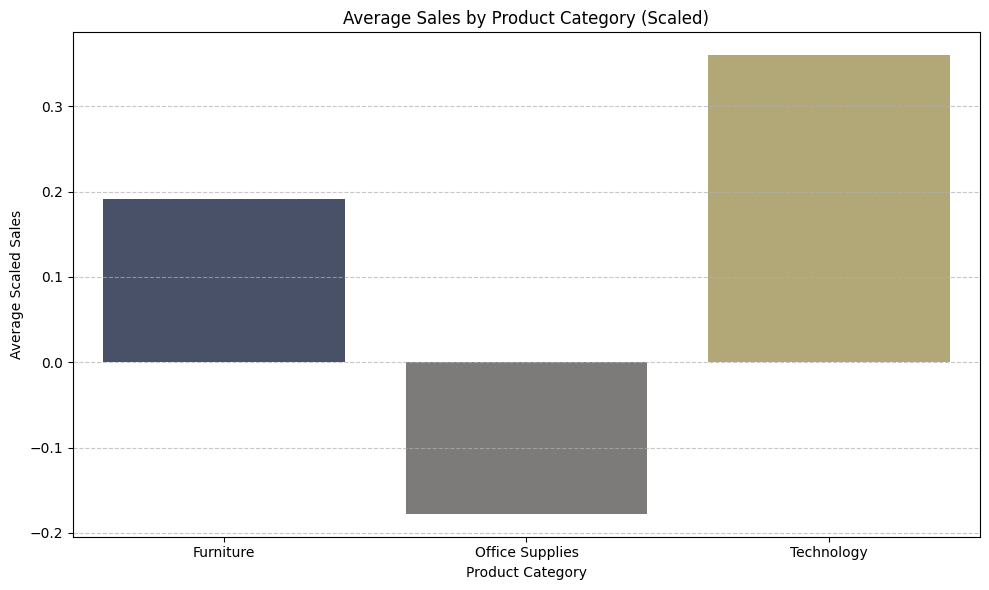

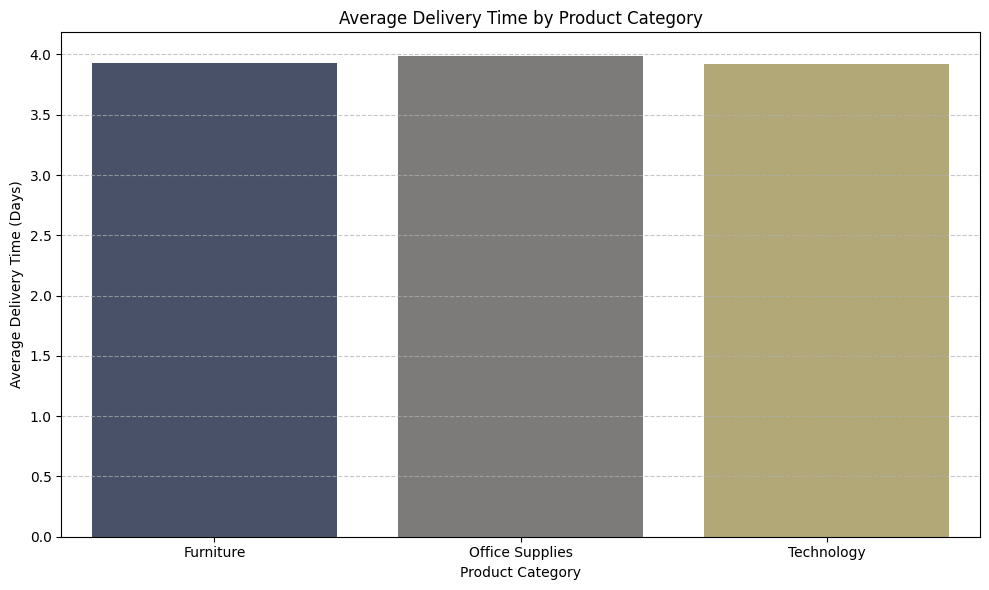

In [25]:
category_analysis = df.groupby('Category').agg(
    avg_sales=('Sales', 'mean'),
    avg_delivery_time=('Delivery Time Days', 'mean')
).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='avg_sales', data=category_analysis, palette='cividis', hue='Category', legend=False)
plt.title('Average Sales by Product Category (Scaled)')
plt.xlabel('Product Category')
plt.ylabel('Average Scaled Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='avg_delivery_time', data=category_analysis, palette='cividis', hue='Category', legend=False)
plt.title('Average Delivery Time by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Delivery Time (Days)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Correlation Heatmap: Sales vs. Delivery Time Days

To directly assess the linear relationship between 'Sales' and 'Delivery Time Days', a correlation heatmap is an effective visualization. This will show us if longer delivery times tend to be associated with higher or lower sales, or if there's no strong linear correlation.

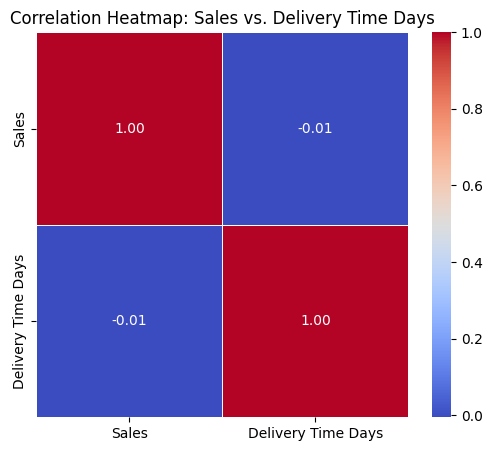

In [26]:
correlation_matrix = df[['Sales', 'Delivery Time Days']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap: Sales vs. Delivery Time Days')
plt.show()

### Average Delivery Time for Top 5 Performing Sub-Categories

Let's analyze the average delivery time for the top 5 sub-categories (based on total sales) to see if delivery speed plays a role in their performance.

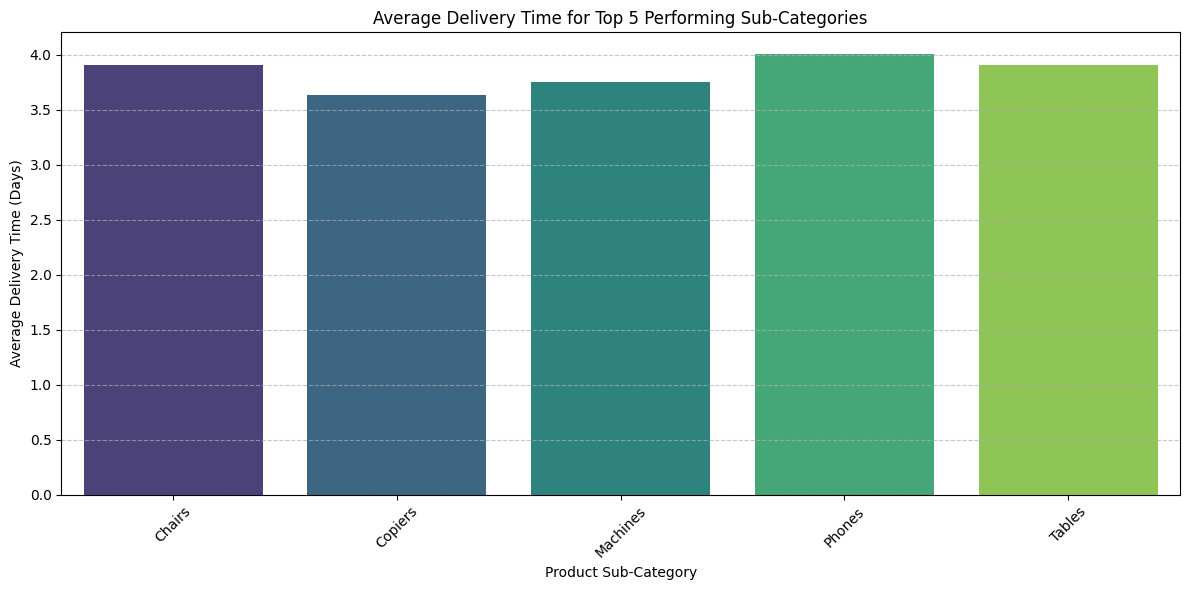

In [27]:
# Identify the top 5 performing sub-categories based on sales
top_5_subcategories = subcategory_sales.head(5)['Sub-Category'].tolist()

# Filter the DataFrame to include only these top sub-categories
df_top_subcategories = df[df['Sub-Category'].isin(top_5_subcategories)]

# Calculate the average delivery time for each of these top sub-categories
delivery_time_top_subcategories = df_top_subcategories.groupby('Sub-Category')['Delivery Time Days'].mean().reset_index()

# Visualize the average delivery times
plt.figure(figsize=(12, 6))
sns.barplot(x='Sub-Category', y='Delivery Time Days', data=delivery_time_top_subcategories, palette='viridis')
plt.title('Average Delivery Time for Top 5 Performing Sub-Categories')
plt.xlabel('Product Sub-Category')
plt.ylabel('Average Delivery Time (Days)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Comparison of Average Delivery Time for Top 5 vs. Bottom 5 Sub-Categories

To understand if delivery time correlates with performance, we'll compare the average delivery times of the top 5 performing sub-categories against the bottom 5.

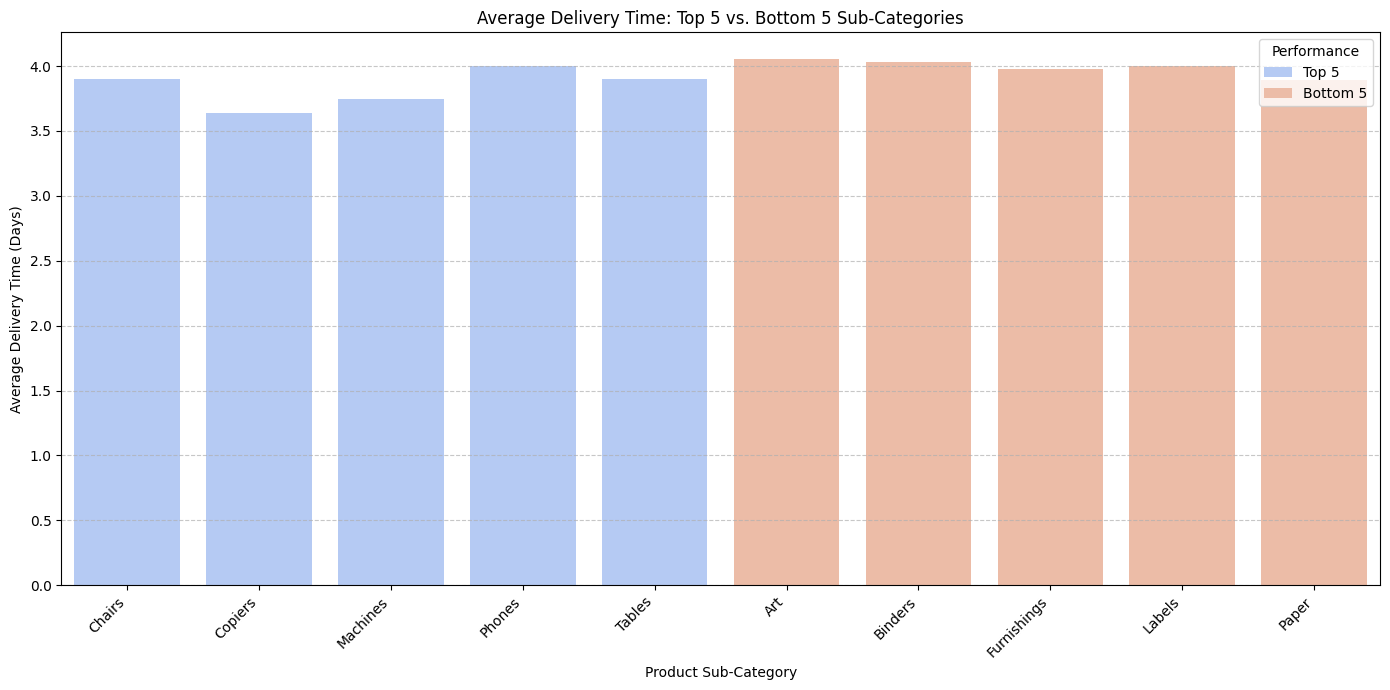

In [28]:
# Identify the bottom 5 performing sub-categories based on sales
bottom_5_subcategories = subcategory_sales.tail(5)['Sub-Category'].tolist()

# Filter the DataFrame to include only these bottom sub-categories
df_bottom_subcategories = df[df['Sub-Category'].isin(bottom_5_subcategories)]

# Calculate the average delivery time for each of these bottom sub-categories
delivery_time_bottom_subcategories = df_bottom_subcategories.groupby('Sub-Category')['Delivery Time Days'].mean().reset_index()

# Add a 'Performance' column to differentiate between top and bottom
delivery_time_top_subcategories['Performance'] = 'Top 5'
delivery_time_bottom_subcategories['Performance'] = 'Bottom 5'

# Concatenate the top and bottom dataframes
combined_delivery_time = pd.concat([delivery_time_top_subcategories, delivery_time_bottom_subcategories])

# Visualize the comparison
plt.figure(figsize=(14, 7))
sns.barplot(x='Sub-Category', y='Delivery Time Days', hue='Performance', data=combined_delivery_time, palette='coolwarm')
plt.title('Average Delivery Time: Top 5 vs. Bottom 5 Sub-Categories')
plt.xlabel('Product Sub-Category')
plt.ylabel('Average Delivery Time (Days)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Average Delivery Time by Region (Line Chart)

Let's visualize the average delivery time for each geographical region using a line chart to observe any regional trends.

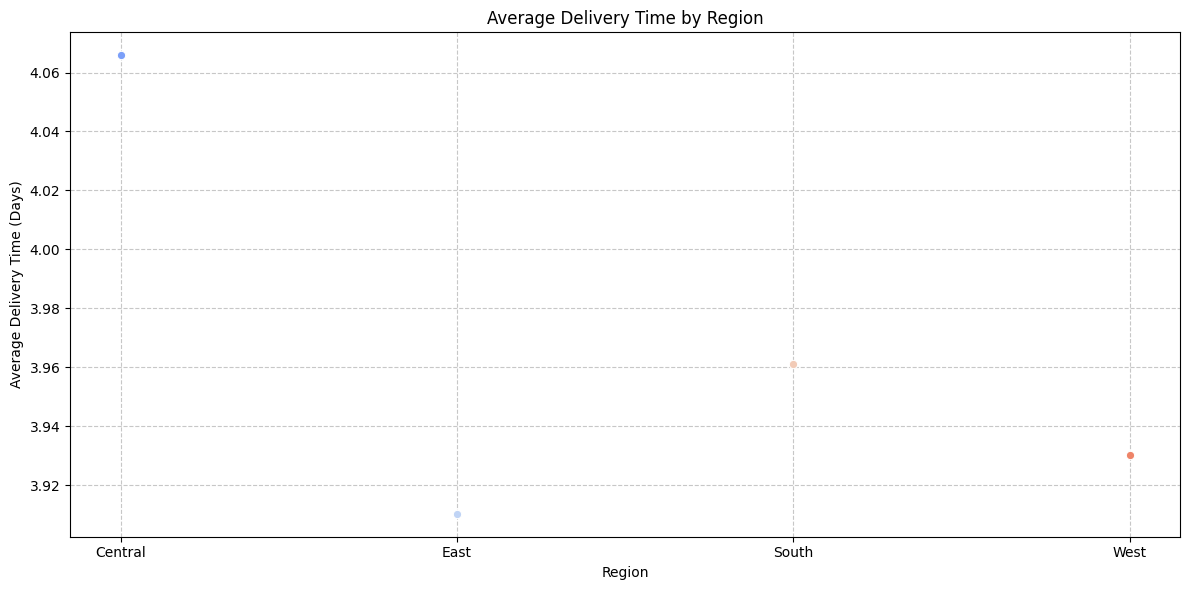

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure region_analysis is available (it was previously calculated and is in kernel state)

plt.figure(figsize=(12, 6))
sns.lineplot(x='Region', y='avg_delivery_time', data=region_analysis, marker='o', palette='coolwarm', hue='Region', legend=False)
plt.title('Average Delivery Time by Region')
plt.xlabel('Region')
plt.ylabel('Average Delivery Time (Days)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Distribution of Delivery Times Across Regions (Box Plot)

Let's use a box plot to visualize the distribution of 'Delivery Time Days' for each 'Region'. This will show us the median, quartiles, and potential outliers for delivery times in each region.

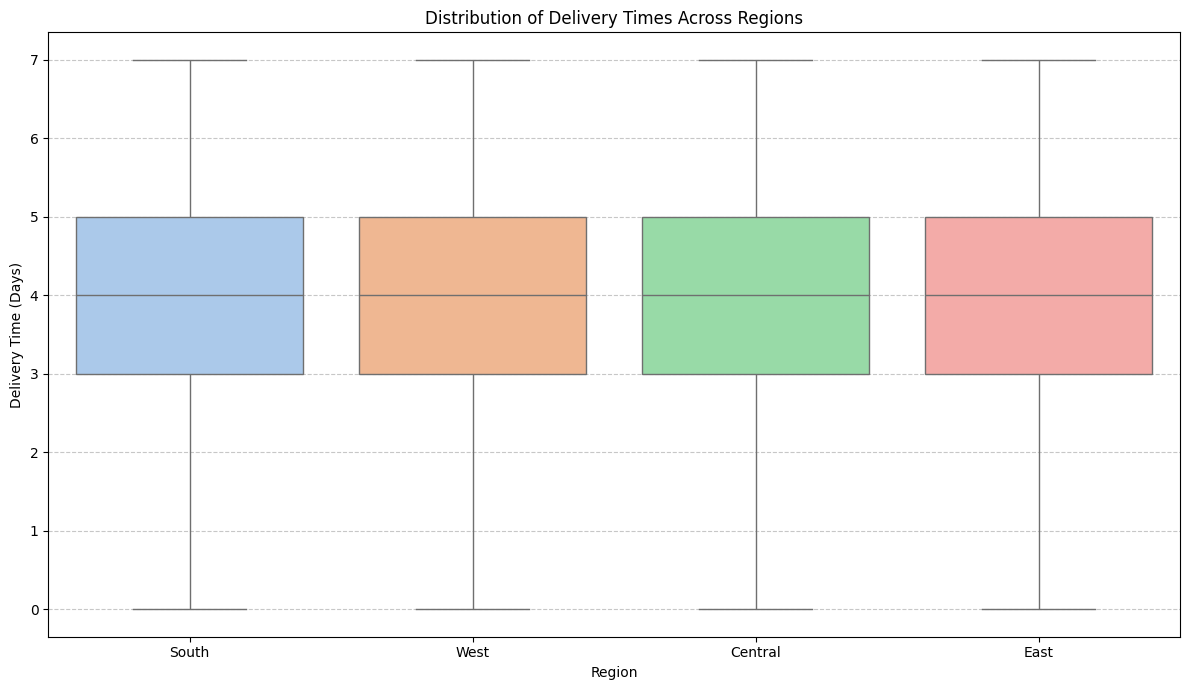

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.boxplot(x='Region', y='Delivery Time Days', data=df, palette='pastel', hue='Region', legend=False)
plt.title('Distribution of Delivery Times Across Regions')
plt.xlabel('Region')
plt.ylabel('Delivery Time (Days)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Scatter Plot: Sales vs. Delivery Time Days

To visually inspect the relationship between 'Sales' and 'Delivery Time Days', a scatter plot is a suitable choice. This will help us observe if there are any discernible patterns, clusters, or outliers.

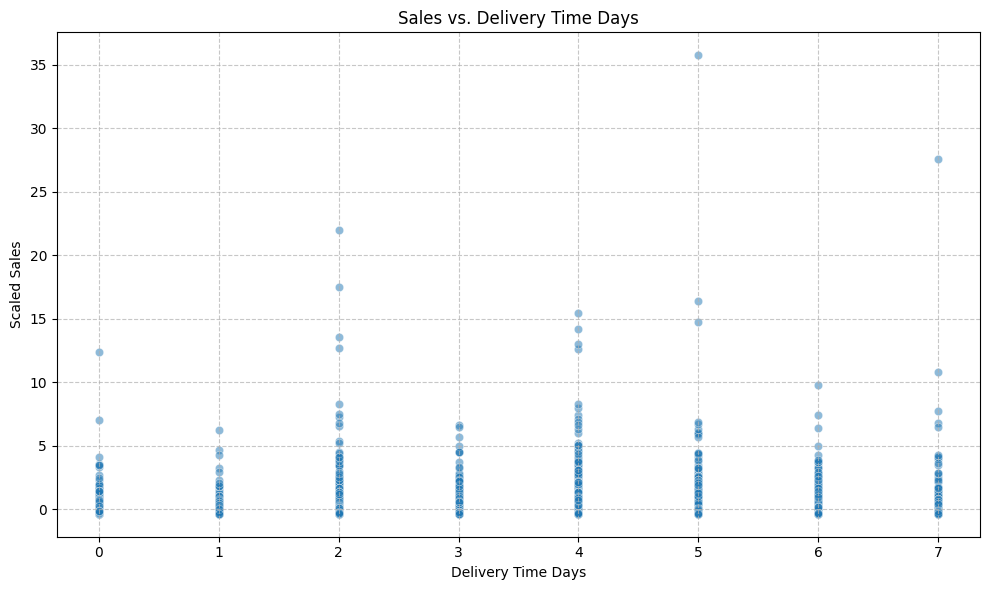

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Delivery Time Days', y='Sales', data=df, alpha=0.5)
plt.title('Sales vs. Delivery Time Days')
plt.xlabel('Delivery Time Days')
plt.ylabel('Scaled Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Based on our analysis of delivery time and sales, here are the key findings:

Sales Trends: We observed monthly sales trends over time, which show fluctuations, but no consistent seasonal pattern emerged from the monthly aggregated sales data. Technology and Furniture categories contribute most to sales, while Office Supplies has negative scaled sales, indicating lower performance.

Impact of Delivery Time on Sales: The correlation heatmap and scatter plot between 'Sales' and 'Delivery Time Days' revealed a very weak negative correlation (-0.0057). This suggests that delivery time has a negligible linear impact on scaled sales in this dataset.

Delivery Time by Customer Segment: Average delivery times are quite consistent across different customer segments (Consumer, Corporate, Home Office), hovering around 3.9 to 4.0 days.
Delivery Time by Region: Similarly, average delivery times are fairly consistent across the Central, East, South, and West regions, also ranging from about 3.9 to 4.0 days.

Delivery Time by Product Category: Average delivery times do not vary significantly across the main product categories (Furniture, Office Supplies, Technology), all falling within a similar narrow range.

Top 5 vs. Bottom 5 Sub-Categories Delivery Time: When comparing the average delivery times of the top 5 performing sub-categories (e.g., Chairs, Machines, Copiers) against the bottom 5 (e.g., Paper, Art, Binders), there isn't a clear distinction. The average delivery times for both groups are quite similar, suggesting that delivery speed is not a primary differentiator for performance within these sub-categories.

In summary, while we analyzed several dimensions, the 'Delivery Time Days' variable appears to have a very minimal linear relationship with 'Sales' in this dataset, and average delivery times are quite stable across different segments, regions, and product categories.

## Sales Prediction for the Next 7 Days

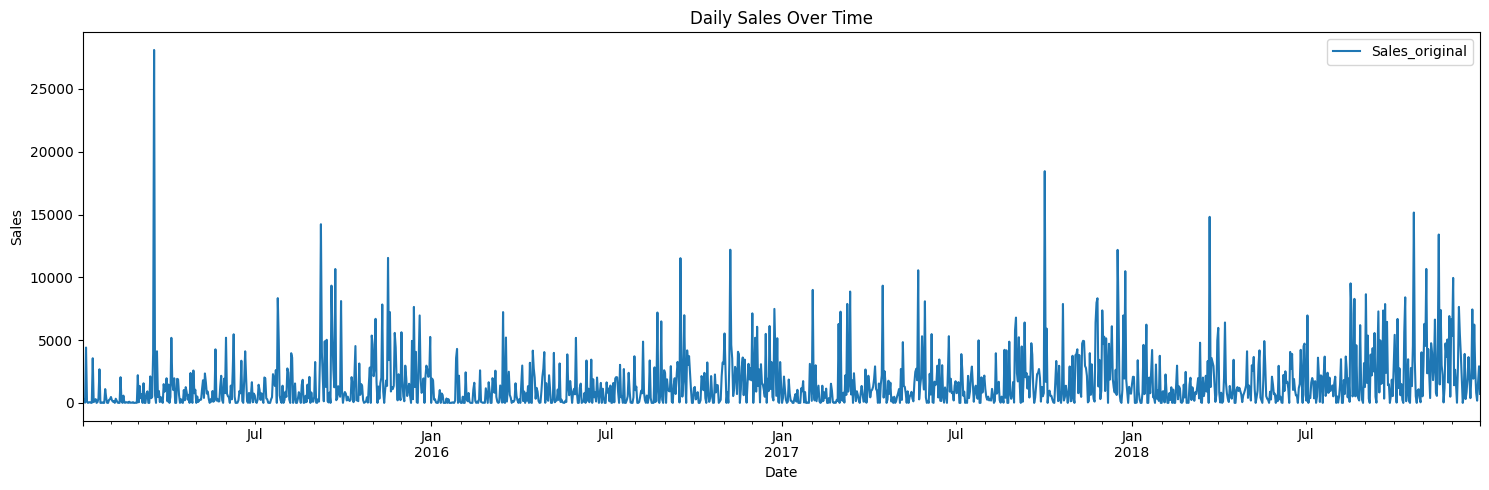

In [32]:
# Reverse the scaling first (original values for forecasting)
df['Sales_original'] = scaler.inverse_transform(df['Sales'].values.reshape(-1, 1))

# Aggregate daily sales
daily_sales = df.groupby('Order Date')['Sales_original'].sum().reset_index()
daily_sales = daily_sales.set_index('Order Date')
daily_sales = daily_sales.asfreq('D', fill_value=0)  # fill missing days with 0

daily_sales.plot(figsize=(15, 5), title='Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

In [33]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_sales['Sales_original'])
print(f'ADF Statistic : {result[0]:.4f}')
print(f'p-value       : {result[1]:.4f}')

if result[1] < 0.05:
    print(" Series is Stationary — ready for ARIMA")
else:
    print(" Series is NOT Stationary — differencing needed (use d=1 in ARIMA)")

ADF Statistic : -4.9266
p-value       : 0.0000
 Series is Stationary — ready for ARIMA


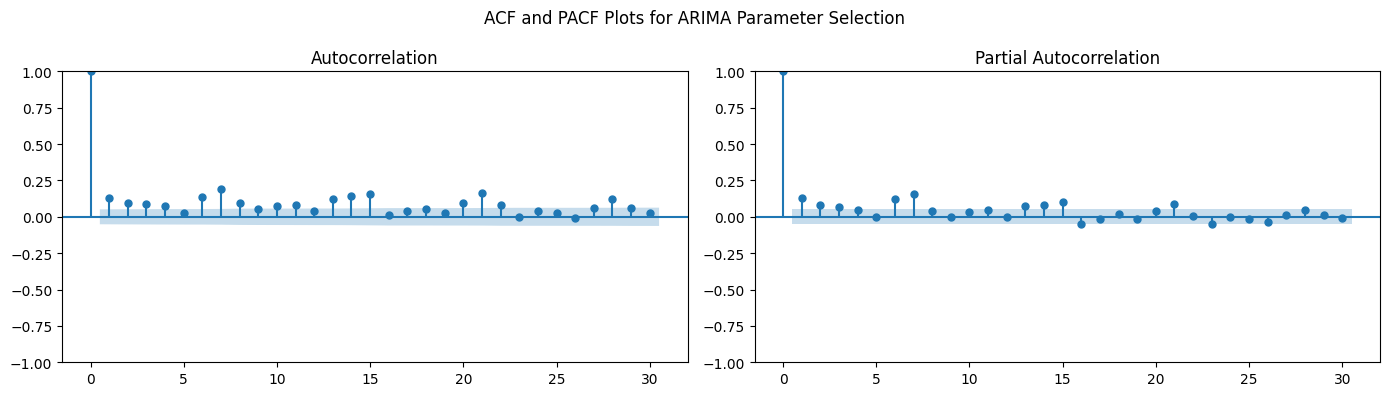

In [34]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(daily_sales['Sales_original'], lags=30, ax=axes[0])
plot_pacf(daily_sales['Sales_original'], lags=30, ax=axes[1])
plt.suptitle('ACF and PACF Plots for ARIMA Parameter Selection')
plt.tight_layout()
plt.show()

In [35]:
# Use last 7 days as test set
train = daily_sales['Sales_original'][:-7]
test  = daily_sales['Sales_original'][-7:]

print(f"Training period : {train.index.min().date()} to {train.index.max().date()}")
print(f"Test period     : {test.index.min().date()}  to {test.index.max().date()}")

Training period : 2015-01-03 to 2018-12-23
Test period     : 2018-12-24  to 2018-12-30


In [36]:
from statsmodels.tsa.arima.model import ARIMA

# p=5, d=1, q=0 is a safe starting point — adjust based on ACF/PACF
model = ARIMA(train, order=(5, 1, 0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:         Sales_original   No. Observations:                 1451
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -13262.663
Date:                Wed, 29 Apr 2026   AIC                          26537.326
Time:                        08:24:28   BIC                          26569.002
Sample:                    01-03-2015   HQIC                         26549.146
                         - 12-23-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7748      0.018    -42.870      0.000      -0.810      -0.739
ar.L2         -0.6149      0.024    -25.610      0.000      -0.662      -0.568
ar.L3         -0.4619      0.026    -17.622      0.0

In [38]:
forecast = model_fit.forecast(steps=7)

# Create forecast date range
last_date = daily_sales.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7)

forecast_df = pd.DataFrame({
    'Date'          : forecast_dates,
    'Predicted_Sales': forecast.values
})
forecast_df.set_index('Date', inplace=True)

print("\n 7-Day Sales Forecast:")
print(forecast_df.round(2))


 7-Day Sales Forecast:
            Predicted_Sales
Date                       
2018-12-31          3022.41
2019-01-01          2902.19
2019-01-02          2753.36
2019-01-03          2975.77
2019-01-04          3882.83
2019-01-05          2895.44
2019-01-06          3075.95


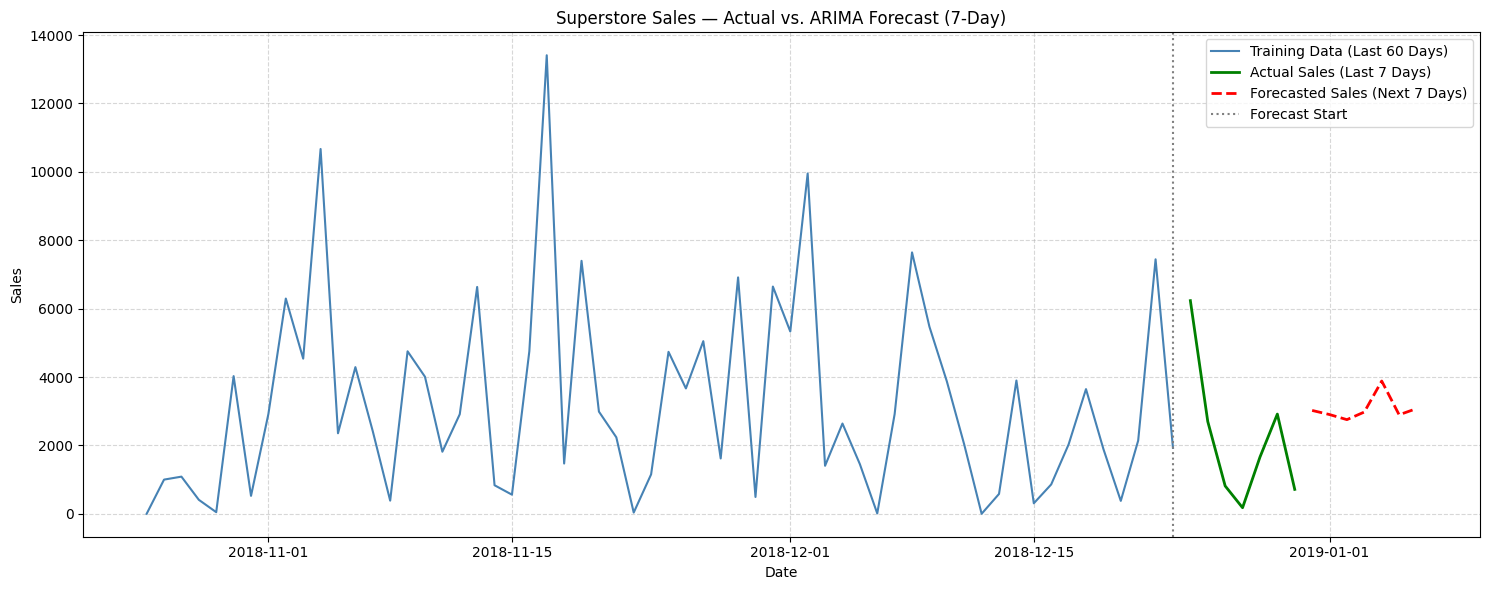

In [39]:
plt.figure(figsize=(15, 6))
plt.plot(train[-60:], label='Training Data (Last 60 Days)', color='steelblue')
plt.plot(test,         label='Actual Sales (Last 7 Days)',  color='green',  linewidth=2)
plt.plot(forecast_df,  label='Forecasted Sales (Next 7 Days)', color='red', linestyle='--', linewidth=2)
plt.axvline(x=train.index[-1], color='gray', linestyle=':', label='Forecast Start')
plt.title('Superstore Sales — Actual vs. ARIMA Forecast (7-Day)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))
mae  = mean_absolute_error(test, forecast)
mape = np.mean(np.abs((test.values - forecast.values) / test.values)) * 100

print(" Model Evaluation Metrics")
print(f"  RMSE : {rmse:.2f}")
print(f"  MAE  : {mae:.2f}")
print(f"  MAPE : {mape:.2f}%")

 Model Evaluation Metrics
  RMSE : 2153.76
  MAE  : 1822.65
  MAPE : 334.02%


In [42]:
print("""
==============================================
   SUPERSTORE SALES FORECAST — PROJECT SUMMARY
==============================================
Dataset      : Superstore Retail Transactions
EDA Scope    : Sales trends, category/region/segment analysis,
               delivery time impact, top & bottom sub-categories
Model Used   : ARIMA (AutoRegressive Integrated Moving Average)
Forecast     : 7-day ahead sales prediction
Metrics      : RMSE, MAE, MAPE
Key Insight  : Delivery time has negligible impact on sales (-0.0057 correlation);
               Technology & Furniture are top revenue drivers.
Tool Stack   : Python, Pandas, Statsmodels, Scikit-learn,
               Matplotlib, Seaborn
==============================================
""")


   SUPERSTORE SALES FORECAST — PROJECT SUMMARY
Dataset      : Superstore Retail Transactions
EDA Scope    : Sales trends, category/region/segment analysis,
               delivery time impact, top & bottom sub-categories
Model Used   : ARIMA (AutoRegressive Integrated Moving Average)
Forecast     : 7-day ahead sales prediction
Metrics      : RMSE, MAE, MAPE
Key Insight  : Delivery time has negligible impact on sales (-0.0057 correlation);
               Technology & Furniture are top revenue drivers.
Tool Stack   : Python, Pandas, Statsmodels, Scikit-learn,
               Matplotlib, Seaborn

